# FOMO-300K Dataset Exploration

This notebook explores the FOMO-300K dataset for normative modeling of dementia.

**Dataset**: FOMO-300K (Federated cOllaborative Learning for Medical iMaging Opendata)  
**Source**: Multi-dataset aggregation of 18+ public neuroimaging datasets  
**Total Records**: 82,680 (before filtering)  
**Focus**: Healthy controls aged ≥45 years with MRI at 1.5T or 3T  
**Session Selection**: First session only per subject per dataset  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import os 
os.chdir(Path().absolute().parent)

## 1. Load Raw FOMO-300K Data

In [2]:
# Load participants data (82,680 records)
print("Loading FOMO-300K participants data...")
participants = pd.read_csv('data/FOMO-300K/participants.tsv', sep='\t')

print(f"Total records: {len(participants):,}")
print(f"Total columns: {len(participants.columns):,}")
print(f"Unique participants: {participants['participant_id'].nunique():,}")
print(f"\nColumns: {list(participants.columns)}")
print(f"\nFirst 5 rows:")
print(participants.head())

Loading FOMO-300K participants data...
Total records: 82,678
Total columns: 7
Unique participants: 4,919

Columns: ['dataset', 'participant_id', 'session_id', 'sex', 'age', 'handedness', 'group']

First 5 rows:
              dataset participant_id session_id sex age handedness    group
0  PT001_ClevelandCCF         sub-01     ses-01   M  30        NaN  Control
1  PT001_ClevelandCCF         sub-02     ses-01   F  29        NaN  Control
2  PT001_ClevelandCCF         sub-03     ses-01   F  57        NaN  Control
3  PT001_ClevelandCCF         sub-04     ses-01   F  45        NaN  Control
4  PT001_ClevelandCCF         sub-05     ses-01   M  33        NaN  Control


In [3]:
# Load MRI scanner information (large file >50MB)
print("\nLoading MRI scanner information (this may take a moment)...")
try:
    mri_info = pd.read_csv('data/FOMO-300K/mri_info.tsv', sep='\t', low_memory=False)
    print(f"MRI info records: {len(mri_info):,}")
    print(f"MRI info columns: {list(mri_info.columns)}")
    print(f"\nFirst 5 rows:")
    print(mri_info.head())
except Exception as e:
    print(f"Note: Could not load full mri_info.tsv. Error: {e}")
    print("Will proceed with participants.tsv only and handle MRI info separately if needed.")
    mri_info = None


Loading MRI scanner information (this may take a moment)...
MRI info records: 318,877
MRI info columns: ['dataset', 'participant_id', 'session_id', 'filename', 'Modality', 'MagneticFieldStrength', 'Manufacturer', 'ManufacturersModelName', 'SoftwareVersions', 'MRAcquisitionType', 'SeriesDescription', 'ProtocolName', 'ScanningSequence', 'SequenceVariant', 'ScanOptions', 'SequenceName', 'EchoTime', 'SliceThickness', 'RepetitionTime', 'InversionTime', 'FlipAngle']

First 5 rows:
              dataset participant_id session_id  \
0  PT001_ClevelandCCF         sub-01     ses-01   
1  PT001_ClevelandCCF         sub-02     ses-01   
2  PT001_ClevelandCCF         sub-03     ses-01   
3  PT001_ClevelandCCF         sub-04     ses-01   
4  PT001_ClevelandCCF         sub-05     ses-01   

                                      filename Modality MagneticFieldStrength  \
0  sub-01/ses-01/anat/sub-01_ses-01_T1w.nii.gz       MR                   3.0   
1  sub-02/ses-01/anat/sub-02_ses-01_T1w.nii.gz    

## 2. Dataset Components Analysis

In [4]:
# Extract dataset identifier from dataset column
participants['dataset_code'] = participants['dataset'].str.split('_').str[0]

print("Dataset distribution (unique participants per dataset):")
unique_participants_per_dataset = participants.groupby('dataset_code')['participant_id'].nunique().sort_index()
print(unique_participants_per_dataset)
print(f"\nTotal unique datasets: {participants['dataset_code'].nunique()}")
print(f"Total unique dataset-site combinations: {participants['dataset'].nunique()}")
total_unique_participants = unique_participants_per_dataset.sum()
print(f"Total unique participants across all datasets: {total_unique_participants:,}")

Dataset distribution (unique participants per dataset):
dataset_code
PT001      31
PT002      82
PT003      51
PT004     163
PT005     973
PT006     105
PT007      53
PT008      51
PT009    2611
PT010     592
PT011      32
PT012     203
PT013     162
PT014    1498
PT015     750
PT016    1639
PT017      13
PT018    3847
PT019      45
PT020    1113
PT021     584
PT022     180
PT023     833
PT024     208
PT025    1135
PT026      50
PT027    1327
PT028     416
PT029     150
PT030    2742
PT031     594
PT032      40
PT033     177
PT034     426
PT035    1430
PT036     232
PT037     131
Name: participant_id, dtype: int64

Total unique datasets: 37
Total unique dataset-site combinations: 920
Total unique participants across all datasets: 24,669


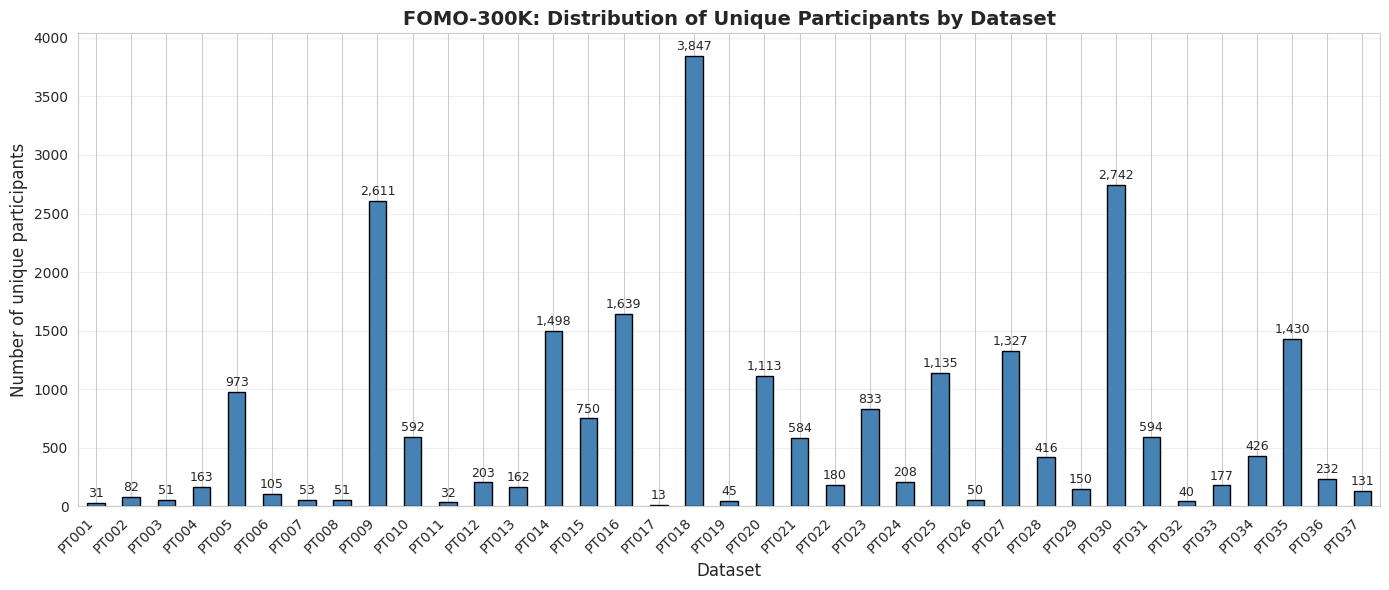


Top 10 dataset-site combinations (by unique participants):
dataset
PT018_HBN                             3847
PT009_BraTS-GEN                       2611
PT030_OpenNeuro/ds004889              1715
PT016_GSP                             1639
PT014_CoRR                            1498
PT035_Yale_Brain_Mets_Longitudinal    1430
PT027_NKI                             1327
PT030_OpenNeuro/ds004169              1202
PT025_MGH_Wild                        1135
PT020_HCP_Wu_Minn                     1113
Name: participant_id, dtype: int64


In [5]:
# Visualize dataset contributions
fig, ax = plt.subplots(figsize=(14, 6))
unique_participants_per_dataset.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Number of unique participants', fontsize=12)
ax.set_title('FOMO-300K: Distribution of Unique Participants by Dataset', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(unique_participants_per_dataset.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 dataset-site combinations (by unique participants):")
unique_per_full_dataset = participants.groupby('dataset')['participant_id'].nunique().sort_values(ascending=False).head(10)
print(unique_per_full_dataset)

## 3. Demographics Analysis (Before Filtering)

In [6]:
# Age distribution (all records)
# Convert age to numeric in the dataframe itself
participants['age'] = pd.to_numeric(participants['age'], errors='coerce')
age_all = participants['age']

print("Age distribution (all records):")
print(f"  Range: {age_all.min():.0f} - {age_all.max():.0f} years")
print(f"  Mean: {age_all.mean():.1f} ± {age_all.std():.1f}")
print(f"  Median: {age_all.median():.0f}")
print(f"  Missing: {age_all.isna().sum():,}")

# Age distribution by dataset
print("\nAge range by dataset (top 10):")
age_by_dataset = participants.groupby('dataset_code')['age'].agg(['min', 'max', 'mean', 'count'])
age_by_dataset = age_by_dataset.sort_values('count', ascending=False).head(10)
print(age_by_dataset)

Age distribution (all records):
  Range: -17 - 100 years
  Mean: 35.3 ± 21.8
  Median: 26
  Missing: 22,123

Age range by dataset (top 10):
                    min         max       mean  count
dataset_code                                         
PT030          0.000000  100.000000  29.894982  30851
PT035        -17.000000   93.000000  60.782521  11877
PT018          5.016997   22.000228  10.325352   3777
PT014          6.000000   88.000000  26.782353   2754
PT027          6.000000   85.000000  32.592802   1945
PT016         19.000000   35.000000  21.541401   1570
PT025          7.000000   94.000000  60.068722   1135
PT031         17.000000   27.000000  19.980639   1033
PT033         18.300000   63.700000  29.471018    835
PT023          0.041096    2.958904   1.135786    833


In [7]:
# Sex distribution
print("Sex distribution (all records):")
sex_counts = participants['sex'].value_counts()
for sex, count in sex_counts.items():
    print(f"  {sex}: {count:,} ({count/len(participants)*100:.1f}%)")

# Handedness distribution
print("\nHandedness distribution:")
hand_counts = participants['handedness'].value_counts(dropna=False)
print(hand_counts)
print(f"Missing handedness: {participants['handedness'].isna().sum():,} ({participants['handedness'].isna().sum()/len(participants)*100:.1f}%)")

Sex distribution (all records):
  F: 33,840 (40.9%)
  M: 29,510 (35.7%)

Handedness distribution:
handedness
NaN    68473
R      12977
L       1120
A        108
Name: count, dtype: int64
Missing handedness: 68,473 (82.8%)


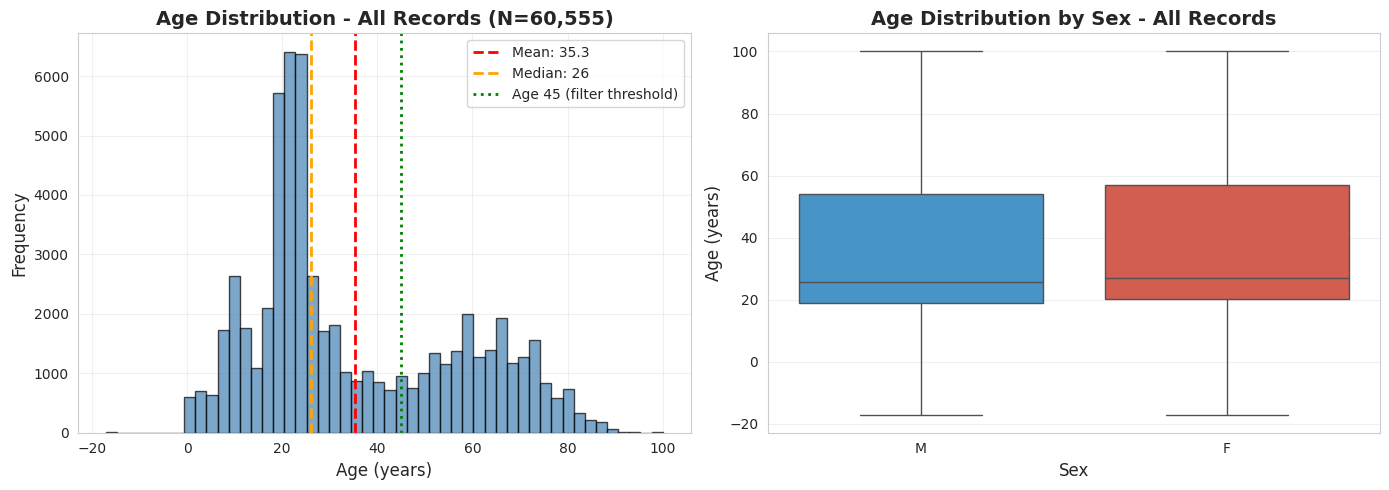

In [8]:
# Visualize age distribution (all records)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall age histogram
axes[0].hist(age_all.dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(age_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_all.mean():.1f}')
axes[0].axvline(age_all.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {age_all.median():.0f}')
axes[0].axvline(45, color='green', linestyle=':', linewidth=2, label='Age 45 (filter threshold)')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Age Distribution - All Records (N={len(age_all.dropna()):,})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Age by sex
sex_palette = {'M': '#3498db', 'F': '#e74c3c'}
participants_plot = participants[participants['age'].notna()].copy()
sns.boxplot(data=participants_plot, x='sex', y='age', palette=sex_palette, ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution by Sex - All Records', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Group/Diagnosis Analysis

In [9]:
# Group distribution
print("Group/diagnosis distribution:")
group_counts = participants['group'].value_counts()
for group, count in group_counts.items():
    print(f"  {group}: {count:,} ({count/len(participants)*100:.1f}%)")

# Control subjects by dataset
print("\nControl subjects by dataset:")
controls_by_dataset = participants[participants['group'] == 'Control']['dataset_code'].value_counts().sort_index()
print(controls_by_dataset)
print(f"\nTotal control subjects: {(participants['group'] == 'Control').sum():,}")

Group/diagnosis distribution:
  Control: 40,215 (48.6%)
  Brain Tumor: 15,263 (18.5%)
  Stroke: 2,500 (3.0%)
  control: 1,753 (2.1%)
  Memory complaints: 1,135 (1.4%)
  Typically Developing: 585 (0.7%)
  normal: 565 (0.7%)
  Typically developing: 473 (0.6%)
  Major depressive disorder: 232 (0.3%)
  AD: 227 (0.3%)
  ADHD-Combined: 212 (0.3%)
  Nondemented: 190 (0.2%)
  CN: 177 (0.2%)
  Brain aneurysm(s): 168 (0.2%)
  Anxiety disorders, disruptive mood dysregulation disorder, or Attention deficit hyperactivity disorder: 163 (0.2%)
  Psychiatric illness: 149 (0.2%)
  Demented: 146 (0.2%)
  ADHD-Inattentive: 137 (0.2%)
  nondemented: 135 (0.2%)
  Disruptive mood dysregulation disorder or attention-deficit hyperactivity disorder: 132 (0.2%)
  CONTROL: 125 (0.2%)
  FTD: 123 (0.1%)
  Intracranial aneurysms: 122 (0.1%)
  Parkinson’s disease: 117 (0.1%)
  Synaesthesia: 102 (0.1%)
  Autism Spectrum Disorder: 97 (0.1%)
  HC: 87 (0.1%)
  Focal cortical dysplasia: 85 (0.1%)
  Cocaine use disorder -

In [10]:
# Cross-tabulation: dataset × group
print("Dataset × Group cross-tabulation (top 15 datasets):")
top_datasets = participants['dataset_code'].value_counts().head(15).index
crosstab = pd.crosstab(
    participants[participants['dataset_code'].isin(top_datasets)]['dataset_code'], 
    participants[participants['dataset_code'].isin(top_datasets)]['group']
)
print(crosstab)

Dataset × Group cross-tabulation (top 15 datasets):
group         ADHD  ADHD-Combined  ADHD-Hyperactive/Impulsive  \
dataset_code                                                    
PT005            0            212                          13   
PT009            0              0                           0   
PT014            0              0                           0   
PT015            0              0                           0   
PT016            0              0                           0   
PT020            0              0                           0   
PT023            0              0                           0   
PT025            0              0                           0   
PT030           41              0                           0   
PT033            0              0                           0   
PT034            0              0                           0   
PT035            0              0                           0   

group         ADHD-Inattentive  Anapl

## 5. Session Analysis

In [11]:
# Session distribution
print("Session distribution:")
session_counts = participants['session_id'].value_counts().sort_index()
print(session_counts.head(10))
print(f"\nTotal unique sessions: {participants['session_id'].nunique()}")

# Subjects with multiple sessions
sessions_per_subject = participants.groupby('participant_id')['session_id'].nunique()
print("\nSubjects by number of sessions:")
print(sessions_per_subject.value_counts().sort_index())
print(f"\nSubjects with multiple sessions: {(sessions_per_subject > 1).sum():,}")

Session distribution:
session_id
ses-01    59969
ses-02     8215
ses-03     3462
ses-04     1998
ses-05     1424
ses-06     1031
ses-07      836
ses-08      699
ses-09      612
ses-10      521
Name: count, dtype: int64

Total unique sessions: 68

Subjects by number of sessions:
session_id
1     2925
2      376
3      322
4      217
5      216
6      133
7      112
8       75
9       71
10      62
11      45
12      32
13      44
14      30
15      36
16      23
17      15
18      21
19      29
20      20
21       6
22      13
23      10
24       5
25      14
26       4
27       7
28      11
29       5
30       8
31       4
32       1
33       2
34       6
35       5
36       1
37       3
38       3
40       1
42       1
47       1
48       1
49       1
66       1
68       1
Name: count, dtype: int64

Subjects with multiple sessions: 1,994


## 6. MRI Scanner Information Analysis

In [12]:
# Merge participants with MRI scanner info
if mri_info is not None:
    print("Merging participants with MRI scanner information...")
    data_merged = participants.merge(
        mri_info,
        on=['dataset', 'participant_id', 'session_id'],
        how='left'
    )
    print(f"Merged records: {len(data_merged):,}")
    print(f"Records with MRI info: {data_merged['MagneticFieldStrength'].notna().sum():,}")
    
    # Field strength distribution
    field_strength = pd.to_numeric(data_merged['MagneticFieldStrength'], errors='coerce')
    print("\nMagnetic Field Strength distribution:")
    print(f"  Non-null values: {field_strength.notna().sum():,} / {len(data_merged):,}")
    if field_strength.notna().sum() > 0:
        print(f"  Range: {field_strength.min():.2f}T - {field_strength.max():.2f}T")
        print(f"  Mean: {field_strength.mean():.2f}T ± {field_strength.std():.2f}T")
        print("\n  Distribution:")
        fs_counts = field_strength.value_counts().sort_index()
        for fs, count in fs_counts.items():
            print(f"    {fs}T: {count:,} ({count/field_strength.notna().sum()*100:.1f}%)")
        
        # Count records with field strength ≤ 3T
        fs_3t_or_less = field_strength <= 3.0
        print(f"\n  Records with field strength ≤3T: {fs_3t_or_less.sum():,} ({fs_3t_or_less.sum()/field_strength.notna().sum()*100:.1f}%)")
    
    # Scanner manufacturer
    if 'Manufacturer' in data_merged.columns:
        print("\nScanner Manufacturer distribution:")
        mfr_counts = data_merged['Manufacturer'].value_counts()
        for mfr, count in mfr_counts.head(10).items():
            print(f"  {mfr}: {count:,}")
else:
    print("MRI info not loaded. Using participants data only.")
    print("Assuming field strength information will be added separately.")
    data_merged = participants.copy()
    data_merged['MagneticFieldStrength'] = np.nan
    print("\nNote: MagneticFieldStrength column added but not populated.")
    print("Will need to process mri_info.tsv separately or in chunks.")

Merging participants with MRI scanner information...
Merged records: 318,877
Records with MRI info: 245,552

Magnetic Field Strength distribution:
  Non-null values: 245,285 / 318,877
  Range: 0.30T - 15000.00T
  Mean: 9.17T ± 305.76T

  Distribution:
    0.3T: 2,274 (0.9%)
    0.7T: 21 (0.0%)
    1.16T: 52 (0.0%)
    1.4939999580383T: 1 (0.0%)
    1.494T: 905 (0.4%)
    1.5T: 32,096 (13.1%)
    2.89362T: 4 (0.0%)
    2.8936200141907T: 34 (0.0%)
    3.0T: 198,883 (81.1%)
    3.95064T: 1,342 (0.5%)
    4.0T: 293 (0.1%)
    6.98T: 3,162 (1.3%)
    7.0T: 6,025 (2.5%)
    9.4T: 86 (0.0%)
    10.5T: 5 (0.0%)
    15000.0T: 102 (0.0%)

  Records with field strength ≤3T: 234,270 (95.5%)

Scanner Manufacturer distribution:
  Siemens: 208,328
  Philips: 20,306
  GE: 13,337
  Ge medical systems: 4,398
  SIEMENS: 2,737
  Ningbo Xingaoyi: 2,230
  GE MEDICAL SYSTEMS: 644
  Philips Medical Systems: 303
  Brucker: 293
  General Electrics: 104


In [18]:
# Confronto pazienti con 7T e 3T della stessa modalità (da filename)
if 'MagneticFieldStrength' in data_merged.columns and 'filename' in data_merged.columns:
    fs = pd.to_numeric(data_merged['MagneticFieldStrength'], errors='coerce')
    tmp = data_merged.copy()
    tmp['MagneticFieldStrength'] = fs
    tmp = tmp[tmp['MagneticFieldStrength'].notna()]
    tmp = tmp[tmp['MagneticFieldStrength'].isin([3.0, 7.0])].copy()

    def modality_from_filename(name):
        if pd.isna(name):
            return None
        d = str(name).lower()
        if 't1' in d or 't1w' in d:
            return 'T1'
        if 't2' in d or 't2w' in d:
            return 'T2'
        return None

    tmp['modality_common'] = tmp['filename'].apply(modality_from_filename)
    tmp = tmp[tmp['modality_common'].notna()].copy()

    per_sub_mod = tmp.groupby(['participant_id', 'modality_common'])['MagneticFieldStrength'].apply(lambda s: set(s)).reset_index()
    both_3_7 = per_sub_mod[per_sub_mod['MagneticFieldStrength'].apply(lambda s: 3.0 in s and 7.0 in s)]
    print(f"Pazienti con sia 3T che 7T (stessa modalità): {len(both_3_7):,}")

    # Export solo pazienti/modi con 3T e 7T
    export_path = "data/FOMO-300K/patients_3T_7T_same_modality_scans.csv"
    export_df = tmp.merge(both_3_7[['participant_id', 'modality_common']], on=['participant_id', 'modality_common'], how='inner')
    export_df = export_df.sort_values(['participant_id', 'modality_common', 'dataset', 'session_id'])
    export_df.to_csv(export_path, index=False)
    print(f"CSV esportato: {export_path}")
else:
    print("MagneticFieldStrength o filename non disponibili: impossibile calcolare 3T vs 7T per modalità")

Pazienti con sia 3T che 7T (stessa modalità): 195
CSV esportato: data/FOMO-300K/patients_3T_7T_same_modality_scans.csv


In [ ]:
export_df

## 7. Apply Filtering Criteria

In [ ]:
excluded_datasets = ["PT002","PT021","PT029","PT019","PT_020"]  


print("=" * 80)
print("APPLYING FILTERING CRITERIA")
print("=" * 80)

# Start with all records
data_filtered = data_merged.copy()
print(f"\nStarting records: {len(data_filtered):,}")

# Filter 1: Only Control group
print("\n[Filter 1] Group == 'Control'")
data_filtered = data_filtered[data_filtered['group'] == 'Control']
print(f"  Remaining: {len(data_filtered):,} records ({len(data_filtered)/len(data_merged)*100:.1f}% of total)")

# Filter 2: Age >= 45
print("\n[Filter 2] Age >= 45")
data_filtered = data_filtered[data_filtered['age'] >= 45]
print(f"  Remaining: {len(data_filtered):,} records ({len(data_filtered)/len(data_merged)*100:.1f}% of total)")

# Filter 3: Field strength 1.5T or 3T only (if available)
if data_filtered['MagneticFieldStrength'].notna().sum() > 0:
    print("\n[Filter 3] MagneticFieldStrength 1.5T or 3.0T only")
    before_fs_filter = len(data_filtered)
    
    # Convert to numeric first
    data_filtered['MagneticFieldStrength'] = pd.to_numeric(data_filtered['MagneticFieldStrength'], errors='coerce')
    
    data_filtered = data_filtered[
        (data_filtered['MagneticFieldStrength'].isin([1.5, 3.0])) | 
        (data_filtered['MagneticFieldStrength'].isna())
    ]
    print(f"  Remaining: {len(data_filtered):,} records ({len(data_filtered)/len(data_merged)*100:.1f}% of total)")
    print(f"  (Note: {data_filtered['MagneticFieldStrength'].isna().sum():,} records have missing field strength)")
else:
    print("\n[Filter 3] MagneticFieldStrength 1.5T or 3.0T only - SKIPPED (no MRI info loaded)")
    print("  Note: This filter should be applied after loading mri_info.tsv")

# Filter 4: First session only per subject
print("\n[Filter 4] First session only per subject")
print(f"  Before: {len(data_filtered):,} records")

# Sort by dataset_code, participant_id and session_id, then take first session per subject per dataset
data_filtered_sorted = data_filtered.sort_values(['dataset_code', 'participant_id', 'session_id'])
data_filtered = data_filtered_sorted.groupby(['dataset_code', 'participant_id']).first().reset_index()

print(f"  After: {len(data_filtered):,} subjects (one session each per subject per dataset)")

if excluded_datasets:
    print(f"\n[Filter 5] Exclude specific datasets: {excluded_datasets}")
    before_exclude = len(data_filtered)
    data_filtered = data_filtered[~data_filtered['dataset_code'].isin(excluded_datasets)]
    print(f"  Remaining: {len(data_filtered):,} subjects ({len(data_filtered)/before_exclude*100:.1f}% of previous)")
else:
    print("\n[Filter 5] No datasets excluded (modify excluded_datasets list if needed)")

print("\n" + "=" * 80)
print(f">>> TOTAL FILTERED SUBJECTS: {len(data_filtered):,} <<<")
print("=" * 80)

## 8. Filtered Dataset Analysis

In [ ]:
# Demographics of filtered dataset
age_filtered = data_filtered['age']

print("Filtered Dataset Demographics:")
print(f"\nAge distribution:")
print(f"  N: {len(age_filtered):,}")
print(f"  Range: {age_filtered.min():.0f} - {age_filtered.max():.0f} years")
print(f"  Mean: {age_filtered.mean():.1f} ± {age_filtered.std():.1f}")
print(f"  Median: {age_filtered.median():.0f}")
print(f"  Q1-Q3: {age_filtered.quantile(0.25):.0f} - {age_filtered.quantile(0.75):.0f}")

print("\nSex distribution:")
sex_counts_filtered = data_filtered['sex'].value_counts()
for sex, count in sex_counts_filtered.items():
    print(f"  {sex}: {count:,} ({count/len(data_filtered)*100:.1f}%)")

print("\nDataset distribution (top 15):")
dataset_counts_filtered = data_filtered['dataset_code'].value_counts().head(15)
for dataset, count in dataset_counts_filtered.items():
    print(f"  {dataset}: {count:,} ({count/len(data_filtered)*100:.1f}%)")

if data_filtered['MagneticFieldStrength'].notna().sum() > 0:
    print("\nField strength distribution:")
    fs_filtered = data_filtered['MagneticFieldStrength'].value_counts().sort_index()
    for fs, count in fs_filtered.items():
        print(f"  {fs}T: {count:,} ({count/data_filtered['MagneticFieldStrength'].notna().sum()*100:.1f}%)")

## 9. Visualizations - Filtered Data

In [ ]:
# Age distribution - filtered
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(age_filtered, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(age_filtered.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_filtered.mean():.1f}')
axes[0].axvline(age_filtered.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {age_filtered.median():.0f}')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Age Distribution - Filtered (N={len(age_filtered):,})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by sex
sex_palette = {'M': '#3498db', 'F': '#e74c3c'}
sns.boxplot(data=data_filtered, x='sex', y='age', palette=sex_palette, ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution by Sex - Filtered', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Dataset contribution - filtered
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 datasets
top15_datasets = data_filtered['dataset_code'].value_counts().head(15)
axes[0].barh(range(len(top15_datasets)), top15_datasets.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top15_datasets)))
axes[0].set_yticklabels(top15_datasets.index)
axes[0].set_xlabel('Number of subjects', fontsize=12)
axes[0].set_title('Top 15 Datasets - Filtered Controls Age ≥45', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()
for i, v in enumerate(top15_datasets.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Sex distribution
sex_counts = data_filtered['sex'].value_counts()
colors = [sex_palette.get(sex, 'gray') for sex in sex_counts.index]
axes[1].bar(range(len(sex_counts)), sex_counts.values, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(sex_counts)))
axes[1].set_xticklabels(sex_counts.index)
axes[1].set_ylabel('Number of subjects', fontsize=12)
axes[1].set_title('Sex Distribution - Filtered', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Age distribution by top datasets
top10_datasets = data_filtered['dataset_code'].value_counts().head(10).index
data_top10 = data_filtered[data_filtered['dataset_code'].isin(top10_datasets)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=data_top10, x='dataset_code', y='age', ax=ax, color='lightblue')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
ax.set_title('Age Distribution by Dataset (Top 10)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Field strength distribution (if available)
if data_filtered['MagneticFieldStrength'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    fs_filtered = data_filtered['MagneticFieldStrength'].dropna()
    fs_counts = fs_filtered.value_counts().sort_index()
    
    ax.bar(range(len(fs_counts)), fs_counts.values, color='green', edgecolor='black', alpha=0.7)
    ax.set_xticks(range(len(fs_counts)))
    ax.set_xticklabels([f'{fs:.1f}T' for fs in fs_counts.index])
    ax.set_ylabel('Number of subjects', fontsize=12)
    ax.set_title('Magnetic Field Strength Distribution - Filtered', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(fs_counts.values):
        ax.text(i, v + 5, f'{v:,}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Field strength visualization skipped (no MRI info loaded)")

## 10. Export Filtered Data

In [ ]:
# Prepare export dataframe with standardized columns
print("Preparing export data...")

# Create standardized output dataframe
output_df = pd.DataFrame({
    'subject_id': data_filtered['participant_id'].values,
    'session_id': data_filtered['session_id'].values,
    'age': data_filtered['age'].values,
    'sex': data_filtered['sex'].values,
    'site': data_filtered['dataset'].values,  # Use full dataset name as site
    'dataset_code': data_filtered['dataset_code'].values,  # Keep original dataset code
    'dataset': 'FOMO-300K'  # Overall dataset name
})

# Add field strength if available
if 'MagneticFieldStrength' in data_filtered.columns:
    output_df['field_strength_T'] = data_filtered['MagneticFieldStrength'].values
else:
    output_df['field_strength_T'] = np.nan
    print("Warning: field_strength_T not available in current data")

# Sort by dataset_code and subject_id
output_df = output_df.sort_values(['dataset_code', 'subject_id']).reset_index(drop=True)

print(f"\nExport dataframe prepared: {len(output_df):,} subjects")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst 10 rows:")
print(output_df.head(10))

In [ ]:
# Identify and exclude overlapping datasets
print("=" * 80)
print("IDENTIFYING OVERLAPPING DATASETS")
print("=" * 80)

# Datasets already processed separately in this project
already_processed = {
    'PT021_IXI': 'IXI (already processed separately)',
    'PT028_OASIS1': 'OASIS1 (included in OASIS combined)',
    'PT029_OASIS2': 'OASIS2 (included in OASIS combined)', 
    # Add HCP components from AABC if identified
    # PT0XX_HCP: 'HCP (subset in AABC)',
}

print("\nDatasets to exclude (already in project):")
for code, reason in already_processed.items():
    if code.split('_')[0] in output_df['dataset_code'].unique():
        n_subjects = (output_df['dataset_code'] == code.split('_')[0]).sum()
        print(f"  {code}: {n_subjects} subjects - {reason}")

# Filter out overlapping datasets
print("\n" + "=" * 80)
print("FILTERING OUT OVERLAPPING DATASETS")
print("=" * 80)

exclude_codes = [code.split('_')[0] for code in already_processed.keys()]
output_df_unique = output_df[~output_df['dataset_code'].isin(exclude_codes)].copy()

print(f"\nBefore exclusion: {len(output_df):,} subjects")
print(f"Excluded subjects: {len(output_df) - len(output_df_unique):,}")
print(f"After exclusion: {len(output_df_unique):,} subjects")

print("\nRemaining datasets:")
remaining_counts = output_df_unique['dataset_code'].value_counts().sort_values(ascending=False)
for dataset, count in remaining_counts.items():
    print(f"  {dataset}: {count:,} subjects")

# Update output_df to unique only
output_df = output_df_unique.copy()

In [ ]:
# Export overall filtered dataset
output_path_overall = 'data/FOMO-300K/fomo_healthy_controls_age45plus.csv'
output_df.to_csv(output_path_overall, index=False)
print(f"✓ Exported {len(output_df):,} subjects to: {output_path_overall}")

In [ ]:
# Export per-dataset CSVs
print("\nExporting per-dataset files...")
export_stats = []

for dataset_code in sorted(output_df['dataset_code'].unique()):
    dataset_data = output_df[output_df['dataset_code'] == dataset_code].copy()
    
    # Create filename
    output_path = f'data/FOMO-300K/fomo_{dataset_code}_controls_age45plus.csv'
    dataset_data.to_csv(output_path, index=False)
    
    # Collect statistics
    stats = {
        'dataset_code': dataset_code,
        'n_subjects': len(dataset_data),
        'age_mean': dataset_data['age'].mean(),
        'age_std': dataset_data['age'].std(),
        'age_min': dataset_data['age'].min(),
        'age_max': dataset_data['age'].max(),
        'n_female': (dataset_data['sex'] == 'F').sum(),
        'n_male': (dataset_data['sex'] == 'M').sum(),
        'pct_female': (dataset_data['sex'] == 'F').sum() / len(dataset_data) * 100
    }
    export_stats.append(stats)
    
    print(f"  ✓ {dataset_code}: {len(dataset_data):4,} subjects → {output_path}")

# Create summary dataframe
export_summary_df = pd.DataFrame(export_stats)
print(f"\nTotal datasets exported: {len(export_stats)}")

In [ ]:
# Save summary statistics to JSON
summary_json = {
    'dataset': 'FOMO-300K',
    'filter_criteria': {
        'group': 'Control',
        'age_min': 45,
        'field_strength_allowed': [1.5, 3.0],
        'session': 'first_only',
        'excluded_datasets': excluded_datasets if excluded_datasets else None
    },
    'total_subjects': len(output_df),
    'age': {
        'mean': float(output_df['age'].mean()),
        'std': float(output_df['age'].std()),
        'min': int(output_df['age'].min()),
        'max': int(output_df['age'].max()),
        'median': float(output_df['age'].median())
    },
    'sex': {
        'female': int((output_df['sex'] == 'F').sum()),
        'male': int((output_df['sex'] == 'M').sum()),
        'female_pct': float((output_df['sex'] == 'F').sum() / len(output_df) * 100)
    },
    'datasets': {
        'n_datasets': int(output_df['dataset_code'].nunique()),
        'datasets': export_summary_df.to_dict('records')
    },
    'export_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

summary_path = 'data/FOMO-300K/fomo_filtering_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f"\n✓ Summary statistics saved to: {summary_path}")

## 10b. Pulizia dati scaricati (sessioni + unzip)

Questa sezione crea un nuovo folder con **solo la sessione scelta** per soggetto e i **file utili già scompattati**.

In [ ]:
from pathlib import Path
import os
import zipfile
import tarfile
import shutil
import tempfile
import pandas as pd

# Paths (modifica se necessario)
csv_path = "data/FOMO-300K/fomo_healthy_controls_age45plus.csv"
raw_root = Path("/media/mario/ArchivioLento/download/FOMO1")
clean_root = Path("/media/mario/ArchivioLento/download/FOMO1_clean")
dry_run = False  # True = non copia/estrai, solo conteggi

df = pd.read_csv(csv_path)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Nessuna colonna trovata tra: {candidates}")

subject_col = pick_col(df, ["subject_id", "participant_id", "sub_id", "subject"])
session_col = pick_col(df, ["session_id", "session", "ses"])
site_col = pick_col(df, ["site", "dataset_site", "site_id"])

if "dataset_code" not in df.columns:
    if "dataset" in df.columns:
        df["dataset_code"] = df["dataset"].astype(str).str.split("_").str[0]
    else:
        df["dataset_code"] = "FOMO"

archive_exts = (".zip", ".tar", ".tar.gz", ".tgz")
keep_exts = (".nii", ".nii.gz", ".json", ".bval", ".bvec")

def is_archive(path: Path) -> bool:
    name = path.name.lower()
    return name.endswith(archive_exts)

def is_keep_file(path: Path) -> bool:
    name = path.name.lower()
    return name.endswith(keep_exts)

def is_t1_file(path: Path) -> bool:
    name = path.name.lower()
    return ("t1" in name or "t1w" in name) and ("t2" not in name) and ("flair" not in name)

def _is_within_directory(directory: Path, target: Path) -> bool:
    abs_directory = os.path.abspath(directory)
    abs_target = os.path.abspath(target)
    return os.path.commonpath([abs_directory]) == os.path.commonpath([abs_directory, abs_target])

def safe_extract_zip(zip_path: Path, dest_dir: Path) -> None:
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.namelist():
            target_path = dest_dir / member
            if not _is_within_directory(dest_dir, target_path):
                raise RuntimeError(f"Percorso non sicuro in zip: {member}")
        zf.extractall(dest_dir)

def safe_extract_tar(tar_path: Path, dest_dir: Path) -> None:
    with tarfile.open(tar_path) as tf:
        for member in tf.getmembers():
            target_path = dest_dir / member.name
            if not _is_within_directory(dest_dir, target_path):
                raise RuntimeError(f"Percorso non sicuro in tar: {member.name}")
        tf.extractall(dest_dir)

def normalize_sub(subject: str) -> str:
    subject = subject.strip()
    return subject if subject.startswith("sub-") else f"sub-{subject}"

def normalize_ses(session: str) -> str:
    session = session.strip()
    return session if session.startswith("ses-") else f"ses-{session}"

def normalize_ds(dataset_code: str) -> str:
    dataset_code = dataset_code.strip()
    return dataset_code if dataset_code.startswith("ds-") else f"ds-{dataset_code}"

def bids_anat_dir(root: Path, dataset_code: str, subject: str, session: str) -> Path:
    return root / "bids" / dataset_code / subject / session / "anat"

def bids_t1w_name(subject: str, session: str, run: int | None = None, suffix: str = ".nii.gz") -> str:
    base = f"{subject}_{session}"
    if run is not None:
        base += f"_run-{run:02d}"
    return f"{base}_T1w{suffix}"

def resolve_subject_dir(site_root: Path, subject_raw: str) -> Path | None:
    direct = site_root / subject_raw
    if direct.exists():
        return direct
    # Alcuni site (es. PT_30) sono raccolte di folder: cerca 1–2 livelli sotto
    candidates = []
    candidates += [p for p in site_root.glob(f"*/{subject_raw}") if p.is_dir()]
    candidates += [p for p in site_root.glob(f"*/*/{subject_raw}") if p.is_dir()]
    return candidates[0] if candidates else None

counts = {
    "subjects": 0,
    "subjects_missing_dir": 0,
    "sessions_found": 0,
    "subjects_using_subject_dir": 0,
    "subjects_with_alt_session_dir": 0,
    "subjects_found_in_nested_site": 0,
    "files_copied": 0,
    "archives_extracted": 0,
    "archives_failed": 0,
    "files_skipped": 0
}

for row in df.itertuples(index=False):
    counts["subjects"] += 1
    subject_raw = str(getattr(row, subject_col))
    session_raw = str(getattr(row, session_col))
    site = str(getattr(row, site_col))
    dataset_code_raw = str(getattr(row, "dataset_code"))

    subject = normalize_sub(subject_raw)
    session = normalize_ses(session_raw)
    dataset_code = normalize_ds(dataset_code_raw)

    site_root = raw_root / site
    raw_subject_dir = resolve_subject_dir(site_root, subject_raw)
    if raw_subject_dir is None:
        counts["subjects_missing_dir"] += 1
        continue
    if raw_subject_dir.parent != site_root:
        counts["subjects_found_in_nested_site"] += 1

    session_dir = raw_subject_dir / session_raw
    if not session_dir.exists():
        candidates = [p for p in raw_subject_dir.glob("ses-*") if p.is_dir()]
        candidates += [p for p in raw_subject_dir.glob(f"*{session_raw}*") if p.is_dir()]
        if candidates:
            session_dir = candidates[0]
            counts["subjects_with_alt_session_dir"] += 1
        else:
            session_dir = raw_subject_dir
            counts["subjects_using_subject_dir"] += 1

    counts["sessions_found"] += 1
    dest_dir = bids_anat_dir(clean_root, dataset_code, subject, session)

    def copy_t1(src: Path, run_idx: int | None = None) -> None:
        suffix = ".nii.gz" if src.name.lower().endswith(".nii.gz") else ".nii"
        out_name = bids_t1w_name(subject, session, run=run_idx, suffix=suffix)
        dest_file = dest_dir / out_name
        if not dry_run:
            dest_dir.mkdir(parents=True, exist_ok=True)
            if not dest_file.exists():
                shutil.copy2(src, dest_file)
        counts["files_copied"] += 1

    run_counter = 1

    for fp in session_dir.rglob("*"):
        if fp.is_dir():
            continue
        if is_archive(fp):
            if not dry_run:
                with tempfile.TemporaryDirectory(prefix="fomo_extract_") as tmp_dir:
                    tmp_extract_dir = Path(tmp_dir)
                    try:
                        if fp.name.lower().endswith(".zip"):
                            safe_extract_zip(fp, tmp_extract_dir)
                        else:
                            safe_extract_tar(fp, tmp_extract_dir)
                        counts["archives_extracted"] += 1
                        for extracted in tmp_extract_dir.rglob("*"):
                            if extracted.is_dir():
                                continue
                            if is_keep_file(extracted) and is_t1_file(extracted):
                                copy_t1(extracted, run_idx=run_counter)
                                run_counter += 1
                            else:
                                counts["files_skipped"] += 1
                    except Exception:
                        counts["archives_failed"] += 1
            else:
                counts["archives_extracted"] += 1
            continue
        if is_keep_file(fp) and is_t1_file(fp):
            copy_t1(fp, run_idx=run_counter)
            run_counter += 1
        else:
            counts["files_skipped"] += 1

print("Pulizia completata (BIDS)")
print(f"Soggetti totali: {counts['subjects']:,}")
print(f"Soggetti senza cartella: {counts['subjects_missing_dir']:,}")
print(f"Soggetti trovati in sotto-folder del site: {counts['subjects_found_in_nested_site']:,}")
print(f"Sessioni trovate: {counts['sessions_found']:,}")
print(f"Sessioni assenti, usata cartella soggetto: {counts['subjects_using_subject_dir']:,}")
print(f"Sessioni trovate con nome alternativo: {counts['subjects_with_alt_session_dir']:,}")
print(f"File copiati (solo T1): {counts['files_copied']:,}")
print(f"Archivi estratti: {counts['archives_extracted']:,}")
print(f"Archivi falliti: {counts['archives_failed']:,}")
print(f"File ignorati: {counts['files_skipped']:,}")
print(f"Output BIDS: {clean_root / 'bids'}")

Pulizia completata (BIDS)
Soggetti totali: 859
Soggetti senza cartella: 0
Soggetti trovati in sotto-folder del site: 0
Sessioni trovate: 859
Sessioni assenti, usata cartella soggetto: 858
Sessioni trovate con nome alternativo: 0
File copiati (solo T1): 1,577
Archivi estratti: 1,513
Archivi falliti: 0
File ignorati: 4,049
Output BIDS: /media/mario/ArchivioLento/download/FOMO1_clean/bids


## 10c. Lista soggetti scaricati

Questa sezione crea una lista verificata di soggetti con file disponibili e genera un CSV compatibile con `run_kube_job` (colonne: `subject_id`, `image_path`, `output_path`). L’`output_path` segue lo standard BIDS in `derivatives/synthseg`.

In [3]:
from pathlib import Path
import pandas as pd

# === CONFIGURA QUI ===
processing = "fastsurfer"  
download_index_csv = Path("data/FOMO-300K/pacs_index.csv")  # opzionale: CSV con colonne subject_id, image_path
bids_root = Path("/mnt/NAS-Progetti/BrainAtrophy/Normative Model/FOMO")  # opzionale: root BIDS (ds-*/sub-*/ses-*/anat)
derivatives_root = bids_root / "derivatives" / processing
output_csv = Path("data/FOMO-300K/fomo_to_process.csv")

# Se output_df non è in memoria, caricalo dalla CSV già esportata
if "output_df" not in globals():
    fallback_csv = Path("data/FOMO-300K/fomo_healthy_controls_age45plus.csv")
    if not fallback_csv.exists():
        raise FileNotFoundError("Manca output_df e non trovo data/FOMO-300K/fomo_healthy_controls_age45plus.csv")
    output_df = pd.read_csv(fallback_csv)

def normalize_sub(value: str) -> str:
    value = str(value).strip()
    return value if value.startswith("sub-") else f"sub-{value}"

def normalize_ses(value: str) -> str:
    value = str(value).strip()
    return value if value.startswith("ses-") else f"ses-{value}"

def normalize_ds(value: str) -> str:
    value = str(value).strip()
    return value if value.startswith("ds-") else f"ds-{value}"

def pick_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def build_bids_path(row: pd.Series) -> Path | None:
    subject = normalize_sub(row["subject_id"])
    ds = normalize_ds(row.get("dataset_code", "FOMO"))
    ses = None
    if "session_id" in row and pd.notna(row["session_id"]):
        ses = normalize_ses(row["session_id"])

    base = bids_root / ds / subject
    if ses:
        base = base / ses
    anat_dir = base / "anat"
    if not anat_dir.exists():
        return None

    if ses:
        candidates = [
            anat_dir / f"{subject}_{ses}_T1w.nii.gz",
            anat_dir / f"{subject}_{ses}_T1w.nii",
        ]
        glob_candidates = list(anat_dir.glob(f"{subject}_{ses}_*T1w.nii*"))
    else:
        candidates = [
            anat_dir / f"{subject}_T1w.nii.gz",
            anat_dir / f"{subject}_T1w.nii",
        ]
        glob_candidates = list(anat_dir.glob(f"{subject}_*T1w.nii*"))

    picked = pick_existing(candidates)
    if picked:
        return picked
    return sorted(glob_candidates)[0] if glob_candidates else None

def make_output_path(row: pd.Series) -> Path:
    subject = normalize_sub(row["subject_id"])
    ds = normalize_ds(row.get("dataset_code", "FOMO"))
    ses = None
    if "session_id" in row and pd.notna(row["session_id"]):
        ses = normalize_ses(row["session_id"])
    base = derivatives_root / ds / subject
    if ses:
        base = base / ses
    return base 

records = []
missing = []

if download_index_csv.exists():
    download_index = pd.read_csv(download_index_csv)
    # normalizza nomi colonna
    col_subject = "subject_id" if "subject_id" in download_index.columns else None
    col_image = "image_path" if "image_path" in download_index.columns else None
    if col_subject is None or col_image is None:
        raise ValueError("pacs_index_csv deve avere colonne: subject_id, image_path")

    merged = output_df.merge(download_index[[col_subject, col_image]], left_on="subject_id", right_on=col_subject, how="left")
    for _, row in merged.iterrows():
        image_path = Path(row[col_image]) if pd.notna(row[col_image]) else None
        if image_path and image_path.exists():
            records.append({
                "subject_id": row["subject_id"],
                "image_path": str(image_path),
                "output_path": str(make_output_path(row)),
                "dataset_code": row.get("dataset_code", "FOMO"),
                "session_id": row.get("session_id", None),
            })
        else:
            missing.append(row["subject_id"])
elif bids_root.exists():
    for _, row in output_df.iterrows():
        image_path = build_bids_path(row)
        if image_path:
            records.append({
                "subject_id": row["subject_id"],
                "image_path": str(image_path),
                "output_path": str(make_output_path(row)),
                "dataset_code": row.get("dataset_code", "FOMO"),
                "session_id": row.get("session_id", None),
            })
        else:
            missing.append(row["subject_id"])
else:
    raise FileNotFoundError("Configura pacs_index_csv o bids_root con un percorso valido.")

pacs_list_df = pd.DataFrame(records)
if not pacs_list_df.empty:
    # garantisci ordine colonne compatibile con run_kube_job
    cols = ["subject_id", "image_path", "output_path", "dataset_code", "session_id"]
    existing_cols = [c for c in cols if c in pacs_list_df.columns]
    pacs_list_df = pacs_list_df[existing_cols]
    pacs_list_df.to_csv(output_csv, index=False)

print("=" * 80)
print("FOMO: PACS verificati")
print(f"Totale soggetti: {len(output_df):,}")
print(f"Con PACS validi: {len(pacs_list_df):,}")
print(f"Senza PACS: {len(missing):,}")
print(f"CSV export: {output_csv}")

if not pacs_list_df.empty and "dataset_code" in pacs_list_df.columns:
    print("\nDistribuzione per dataset (PACS validi):")
    ds_counts = pacs_list_df["dataset_code"].value_counts().sort_index()
    for ds, count in ds_counts.items():
        print(f"  {ds}: {count:,}")
print("=" * 80)

FOMO: PACS verificati
Totale soggetti: 859
Con PACS validi: 850
Senza PACS: 9
CSV export: data/FOMO-300K/fomo_to_process.csv

Distribuzione per dataset (PACS validi):
  PT001: 15
  PT014: 190
  PT030: 517
  PT032: 20
  PT033: 19
  PT034: 81
  PT036: 8
